In [ ]:
from google.colab import drive
drive.mount('/content/drive')          # mounts your Google Drive

import os                              # for folder & file navigation
import numpy as np                     # for numerical operations & arrays
import matplotlib.pyplot as plt        # for plotting graphs & images
import seaborn as sns                  # for styled charts
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
# load_img      → opens image file from disk (like open() for text files)
# img_to_array  → converts opened image into numpy array (height, width, 3)

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/Data'   # path to your 3 folders in Drive

classes = os.listdir(dataset_path)             # lists all folders inside Data
print("Classes found:", classes)               # should print 3 class names

for cls in classes:
    cls_path = os.path.join(dataset_path, cls) # joins path + folder name
    print(f"{cls}: {len(os.listdir(cls_path))} images")  # counts images per class

Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Bacterial leaf blight: 40 images
Brown spot: 40 images
Leaf smut: 39 images


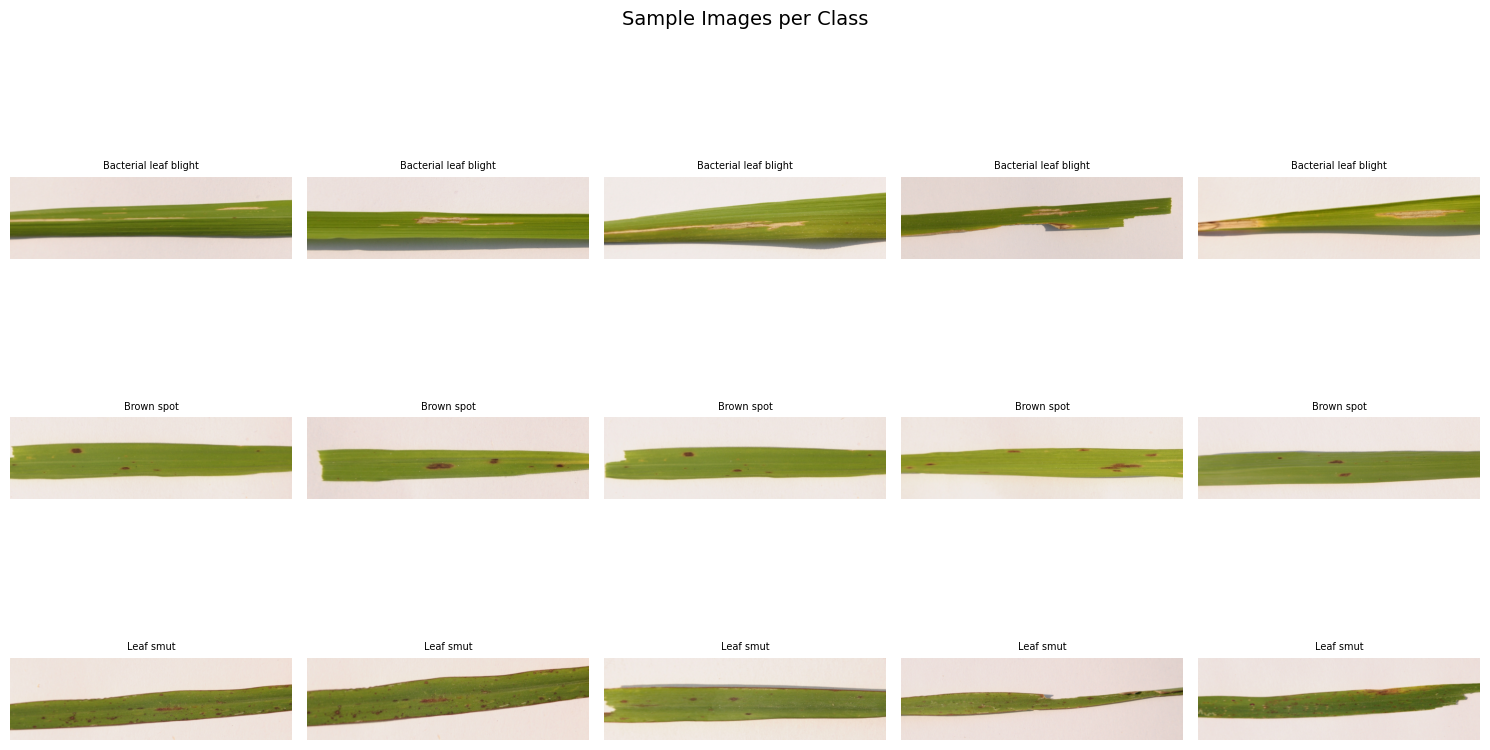

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
# 3 rows (one per class) x 5 columns (5 sample images each)

fig.suptitle('Sample Images per Class', fontsize=14)

for row, cls in enumerate(classes):
    # enumerate gives row index + class name together

    cls_path = os.path.join(dataset_path, cls)
    # full path to that class folder

    images = os.listdir(cls_path)[:5]
    # grab first 5 image filenames

    for col, img_name in enumerate(images):
        img = load_img(os.path.join(cls_path, img_name))
        # load_img opens the image using Keras

        axes[row, col].imshow(img)
        # display image at grid position [row, col]

        axes[row, col].set_title(cls, fontsize=7)
        axes[row, col].axis('off')
        # hide axis lines — cleaner look

plt.tight_layout()
plt.show()

In [ ]:
print("Image Size & Mode check:\n")

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    # full path to each class folder

    img = load_img(os.path.join(cls_path, os.listdir(cls_path)[0]))
    # os.listdir(cls_path)[0] → picks the first image filename in the folder
    # load_img → opens that image

    img_array = img_to_array(img)
    # converts image to numpy array

    print(f"{cls}")
    print(f"  Size  : {img.size}")
    # img.size → returns (width, height) of the image

    print(f"  Shape : {img_array.shape}")
    # img_array.shape → returns (height, width, channels)
    # channels = 3 means RGB
    print()

Image Size & Mode check:

Bacterial leaf blight
  Size  : (3081, 897)
  Shape : (897, 3081, 3)

Brown spot
  Size  : (3081, 897)
  Shape : (897, 3081, 3)

Leaf smut
  Size  : (3081, 897)
  Shape : (897, 3081, 3)



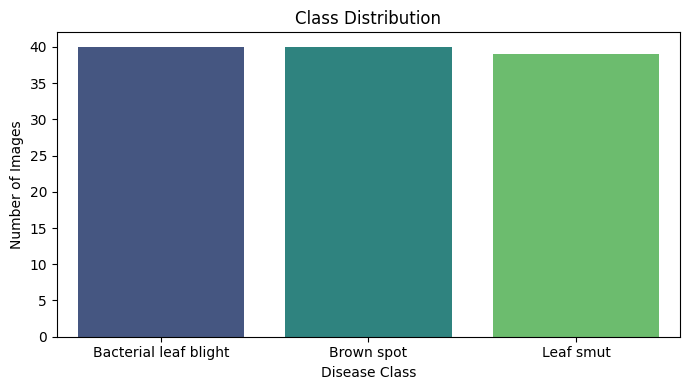

In [ ]:
counts = [len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes]
# list comprehension — counts number of images in each class folder
# os.path.join joins dataset_path + class name
# len() counts the images

plt.figure(figsize=(7, 4))
# creates a figure of width 7, height 4 inches

sns.barplot(x=classes, y=counts, palette='viridis')
# x = class names on x axis
# y = image counts on y axis
# palette = color theme

plt.title('Class Distribution')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

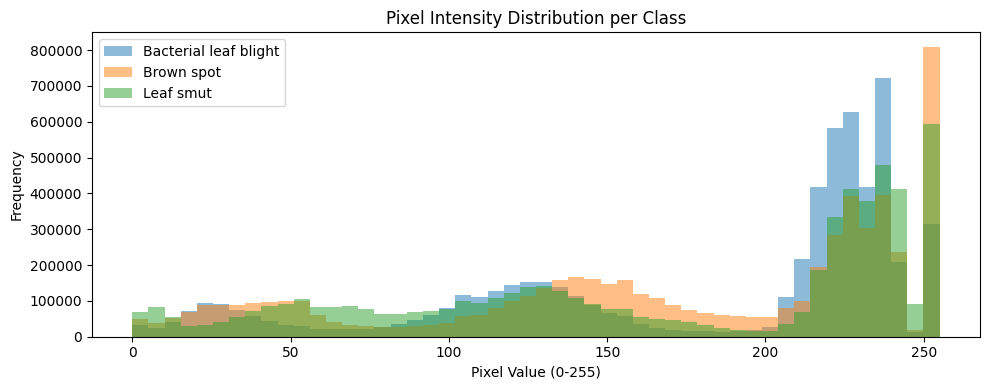

In [ ]:
plt.figure(figsize=(10, 4))

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    # full path to each class folder

    pixels = []
    # empty list to store all pixel values for this class

    for img_name in os.listdir(cls_path):
        img = load_img(os.path.join(cls_path, img_name), target_size=(224, 224))
        # load and resize to 224x224 — avoids memory issues with 3081x897 originals

        img_array = img_to_array(img)
        # convert to numpy array → shape (224, 224, 3)

        pixels.extend(img_array.flatten().tolist())
        # flatten() → converts (224,224,3) to 1D array of all pixel values
        # extend() → adds all those values to the pixels list

    plt.hist(pixels, bins=50, alpha=0.5, label=cls)
    # plots histogram of pixel values (0-255) for this class
    # alpha=0.5 → transparency so overlapping lines are visible
    # bins=50 → divides 0-255 range into 50 buckets

plt.title('Pixel Intensity Distribution per Class')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

X = []
y = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(cls_path):
        img = load_img(os.path.join(cls_path, img_name), target_size=(224, 224))
        # load and resize to 224x224

        img_array = img_to_array(img)
        # shape: (224, 224, 3)

        img_array = img_array / 255.0
        # normalize to 0-1 range
        # CNN trains better with small values than raw 0-255

        X.append(img_array)
        y.append(cls)
        # cls is the folder name = class label

X = np.array(X)
# convert list → numpy array
# final shape: (119, 224, 224, 3)

y = np.array(y)

print("X shape:", X.shape)   # (119, 224, 224, 3)
print("y shape:", y.shape)   # (119,)
print("Classes:", np.unique(y))

X shape: (119, 224, 224, 3)
y shape: (119,)
Classes: ['Bacterial leaf blight' 'Brown spot' 'Leaf smut']


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes in y:", np.unique(y))

X shape: (119, 224, 224, 3)
y shape: (119,)
Classes in y: ['Bacterial leaf blight' 'Brown spot' 'Leaf smut']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
# converts strings → integers
# 'Bacterial leaf blight' → 0, 'Brown spot' → 1, 'Leaf smut' → 2

print("y_encoded:", y_encoded[:119])        # first 10 encoded labels
print("Classes mapping:", list(le.classes_))  # shows which index = which class

y_categorical = to_categorical(y_encoded, num_classes=3)
# converts integers → one-hot encoded vectors
# 0 → [1, 0, 0]
# 1 → [0, 1, 0]
# 2 → [0, 0, 1]

print("y_categorical shape:", y_categorical.shape)  # should be (119, 3)
print("Sample one-hot:", y_categorical[:3])

y_encoded: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2]
Classes mapping: [np.str_('Bacterial leaf blight'), np.str_('Brown spot'), np.str_('Leaf smut')]
y_categorical shape: (119, 3)
Sample one-hot: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (95, 224, 224, 3)
X_val shape: (24, 224, 224, 3)
y_train shape: (95, 3)
y_val shape: (24, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.3474 - loss: 3.2547 - val_accuracy: 0.3333 - val_loss: 2.0082
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2737 - loss: 1.6332 - val_accuracy: 0.3333 - val_loss: 1.1676
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.3158 - loss: 1.1721 - val_accuracy: 0.3333 - val_loss: 1.0823
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3789 - loss: 1.1021 - val_accuracy: 0.4167 - val_loss: 1.0774
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4737 - loss: 1.0343 - val_accuracy: 0.5833 - val_loss: 1.0406
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4737 - loss: 1.0521 - val_accuracy: 0.5000 - val_loss: 0.9959
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4526 - loss: 1.0518 - val_accuracy: 0.3750 - val_loss: 1.0258
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5895 - loss: 0.8939 - val_accuracy: 0.4167 - val_loss: 1.0

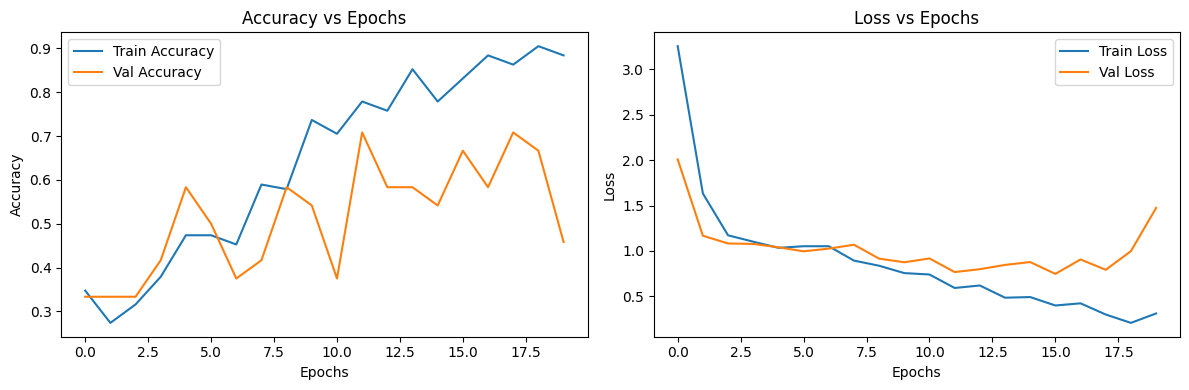

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.47      1.00      0.64         8
           Brown spot       0.25      0.12      0.17         8
            Leaf smut       0.67      0.25      0.36         8

             accuracy                           0.46        24
            macro avg       0.46      0.46      0.39        24
         weighted avg       0.46      0.46      0.39        24



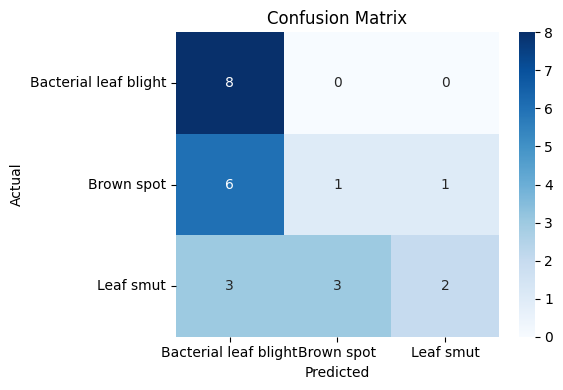

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# get predictions
y_pred = model.predict(X_val)
# model outputs probabilities like [0.1, 0.7, 0.2]

y_pred_classes = np.argmax(y_pred, axis=1)
# argmax picks the index with highest probability → 1

y_true = np.argmax(y_val, axis=1)
# convert one-hot back to integers for comparison

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

# confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# upload from local PC
uploaded = files.upload()
# this will show a "Choose Files" button in Colab
# select any rice leaf image from your PC

# get the filename
img_path = list(uploaded.keys())[0]
# uploaded is a dict → key is filename, value is file bytes

# preprocess same way as training data
img = load_img(img_path, target_size=(224, 224))
# resize to 224x224 — must match what model was trained on

img_array = img_to_array(img)
# shape: (224, 224, 3)

img_array = img_array / 255.0
# normalize — same as training

img_array = np.expand_dims(img_array, axis=0)
# shape becomes (1, 224, 224, 3)
# model expects batch dimension — even for single image

# predict
pred = model.predict(img_array)
print("Raw probabilities:", pred)
# e.g. [[0.1, 0.7, 0.2]]

pred_class = np.argmax(pred, axis=1)
print("Predicted class index:", pred_class)

pred_label = le.classes_[pred_class[0]]
print("Predicted label:", pred_label)

Saving DSC_0389.JPG to DSC_0389.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
Raw probabilities: [[9.9999785e-01 1.7543795e-06 3.3139443e-07]]
Predicted class index: [0]
Predicted label: Bacterial leaf blight


In [ ]:
test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f"Val Loss: {test_loss:.4f}")
print(f"Val Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4583 - loss: 1.4734
Val Loss: 1.4734
Val Accuracy: 0.4583
